# K-Nearest Neighbor(KNN).
Is a non-parametric, instance-based learning method. It operates for classification as well as regression:

K-Nearest Neighbors (KNN) is a simple way to classify things by looking at what’s nearby.

Imagine a streaming service wants to predict if a new user is likely to cancel their subscription (churn) based on their age.

They checks the ages of its existing users and whether they churned or stayed. 

If most of the “K” closest users in age of new user canceled their subscription KNN will predict the new user might churn too. 

The key idea is that users with similar ages tend to have similar behaviors and KNN uses this closeness to make decisions.

## ‘K’ in K Nearest Neighbour.
In the k-Nearest Neighbours (k-NN) algorithm k is just a number that tells the algorithm how many nearby points (neighbours) to look at when it makes a decision.

you’re deciding which fruit it is based on its shape and size. You compare it to fruits you already know.

If k = 3, the algorithm looks at the 3 closest fruits to the new one.

If 2 of those 3 fruits are apples and 1 is a banana, the algorithm says the new fruit is an apple because most of its neighbours are apples.

## How to choose the value of k for KNN Algorithm
If the dataset has significant outliers or noise a higher k can help smooth out the predictions and reduce the influence of noisy data. However choosing very high value can lead to underfitting where the model becomes too simplistic.

A smaller k value makes the model sensitive to noise, leading to overfitting (complex models).

A larger k value results in smoother boundaries, reducing model complexity but possibly underfitting.

Statistical Methods for Selecting k:

Cross-Validation: A robust method for selecting the best k is to perform k-fold cross-validation. This involves splitting the data into k subsets training the model on some subsets and testing it on the remaining ones and repeating this for each subset. The value of k that results in the highest average validation accuracy is usually the best choice.

Elbow Method: In the elbow method we plot the model’s error rate or accuracy for different values of k. As we increase k the error usually decreases initially. However after a certain point the error rate starts to decrease more slowly. This point where the curve forms an “elbow” that point is considered as best k.


Odd Values for k: It’s also recommended to choose an odd value for k especially in classification tasks to avoid ties when deciding the majority class.

## Distance Metrics Used in KNN Algorithm
KNN uses distance metrics to identify nearest neighbour, these neighbours are used for classification and regression task. To identify nearest neighbour we use below distance metrics:

1. Euclidean Distance

Euclidean distance is defined as the straight-line distance between two points in a plane or space.

2. Manhattan Distance

This is the total distance you would travel if you could only move along horizontal and vertical lines (like a grid or city streets).

3. Minkowski Distance

Minkowski distance is like a family of distances, which includes both Euclidean and Manhattan distances as special cases.

## Step-by-Step explanation of how KNN works
Step 1: Selecting the optimal value of K

K represents the number of nearest neighbors that needs to be considered while making prediction.

Step 2: Calculating distance

To measure the similarity between target and training data points Euclidean distance is used. Distance is calculated between data points in the dataset and target point.

Step 3: Finding Nearest Neighbors

The k data points with the smallest distances to the target point are nearest neighbors.

Step 4: Voting for Classification or Taking Average for Regression

When you want to classify a data point into a category (like spam or not spam), the K-NN algorithm looks at the K closest points in the dataset. 

These closest points are called neighbors. The algorithm then looks at which category the neighbors belong to and picks the one that appears the most. This is called majority voting.

In regression, the algorithm still looks for the K closest points. But instead of voting for a class in classification, it takes the average of the values of those K neighbors. This average is the predicted value for the new point for the algorithm.


# Python Implementation of KNN Algorithm:


In [2]:
#  Importing Libraries
import numpy as np
from collections import Counter

"""
Counter: is used to count the occurrences of elements in a list or iterable. 
In KNN after finding the k nearest neighbors labels Counter helps count how many times each label appears
"""

'\nCounter: is used to count the occurrences of elements in a list or iterable. \nIn KNN after finding the k nearest neighbors labels Counter helps count how many times each label appears\n'

In [3]:
# Defining the Euclidean Distance Function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))))

In [4]:
# KNN Prediction Function
def knn_predict(training_data, training_labels, test_point,k):
    distance = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distance.append((dist, training_data[i]))
    distance.sort(key=lambda x: x[0])  
    k_nearest_labels = [label for _, label in distance[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]  

"""
distances.append: Each distance is paired with the corresponding label (training_labels[i]) of the training data. 
This pair is stored in a list called distances.

distances.sort: The list of distances is sorted in ascending order so that the closest points are at the beginning of the list.

k_nearest_labels: The function then selects the labels of the k closest neighbors.

The labels of the k nearest neighbors are counted using the Counter class,
and the most frequent label is returned as the prediction for the test_point.
This is based on the majority vote of the k neighbors.
"""

'\ndistances.append: Each distance is paired with the corresponding label (training_labels[i]) of the training data. \nThis pair is stored in a list called distances.\n\ndistances.sort: The list of distances is sorted in ascending order so that the closest points are at the beginning of the list.\n\nk_nearest_labels: The function then selects the labels of the k closest neighbors.\n\nThe labels of the k nearest neighbors are counted using the Counter class,\nand the most frequent label is returned as the prediction for the test_point.\nThis is based on the majority vote of the k neighbors.\n'

In [ ]:
# Training Data, Labels and Test Point
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3
training_data

([1, 2], [2, 3], [3, 4], [6, 7], [7, 8])

In [42]:
# Prediction and Output
#prediction = knn_predict(training_data, training_labels, test_point, k)
#print(prediction)


# We’ll use the Iris dataset, a well-known dataset for classification

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [84]:
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target  # Add target labels

# Map target numbers to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display dataset info
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000   

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


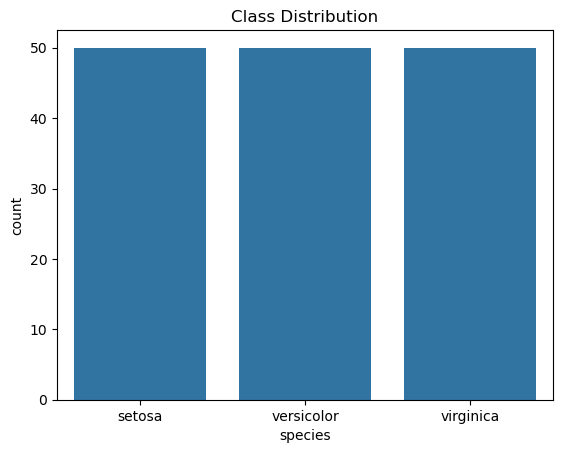

In [85]:
# Check dataset summary
print(df.describe(),'\n')

# Check for missing values
print(df.isnull().sum())

# Visualize class distribution
sns.countplot(x='species', data=df)
plt.title("Class Distribution")
plt.show()

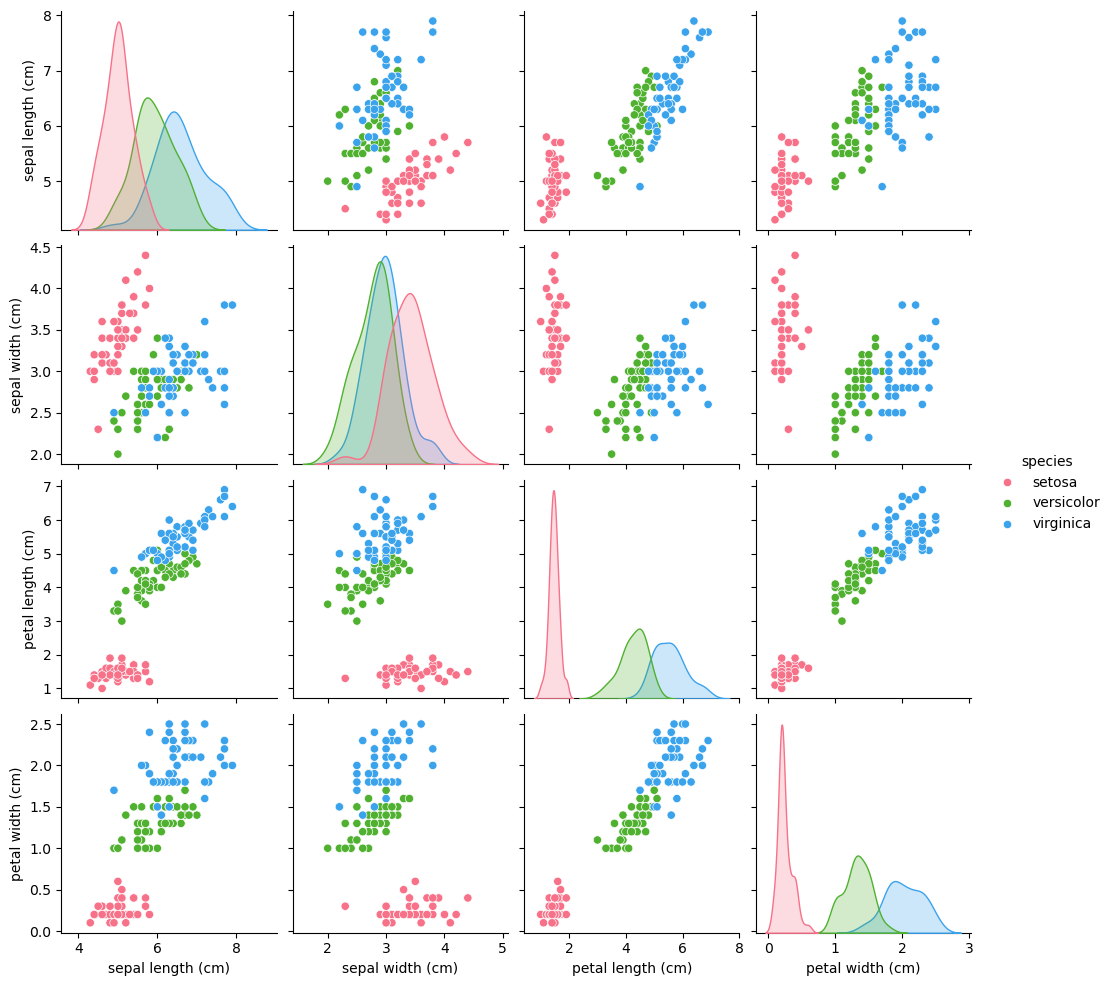

In [91]:
# Pair plot for all numerical features
sns.pairplot(df, hue="species", palette="husl")
plt.show()


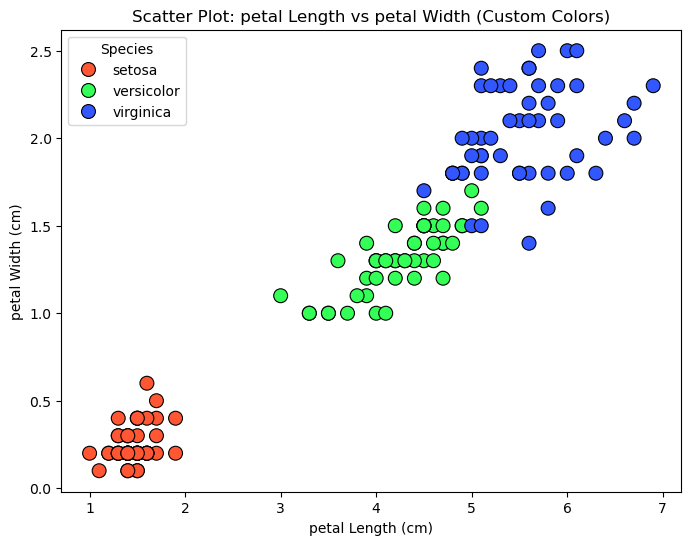

In [95]:
# Custom color scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['petal length (cm)'], 
    y=df['petal width (cm)'], 
    hue=df['species'], 
    palette=['#FF5733', '#33FF57', '#3357FF'],  # Custom colors
    s=100,  # Size of points
    edgecolor='black'
)
plt.xlabel("petal Length (cm)")
plt.ylabel("petal Width (cm)")
plt.title("Scatter Plot: petal Length vs petal Width (Custom Colors)")
plt.legend(title="Species")
plt.show()


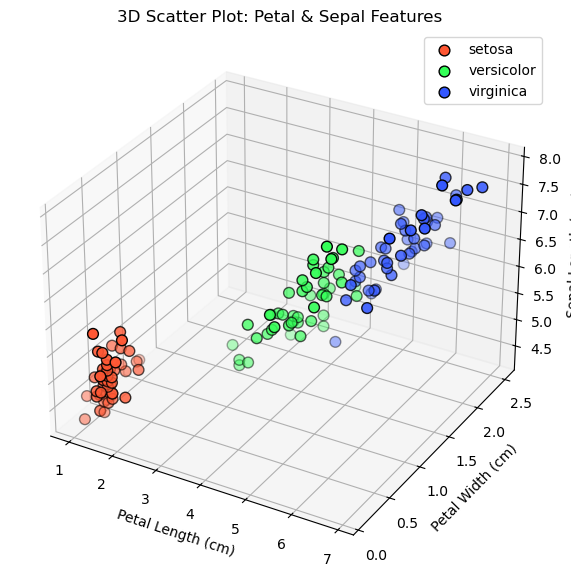

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define colors for each species
colors = {'setosa': '#FF5733', 'versicolor': '#33FF57', 'virginica': '#3357FF'}

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each species with a unique color
for species in df['species'].unique():
    species_data = df[df['species'] == species]
    ax.scatter(
        species_data['petal length (cm)'], 
        species_data['petal width (cm)'], 
        species_data['sepal length (cm)'], 
        color=colors[species], 
        label=species,
        s=60,  # Point size
        edgecolor='black'
    )

ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.set_zlabel("Sepal Length (cm)")
ax.set_title("3D Scatter Plot: Petal & Sepal Features")
ax.legend()
plt.show()


In [86]:
"""
Convert categorical labels to numerical (if needed)

Scale numerical features for better performance
"""

# Separate features and target variable
X = df.drop(columns=['species'])  # Features
y = df['species']  # Target

# Scale features for better performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [87]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 120, Testing samples: 30


Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



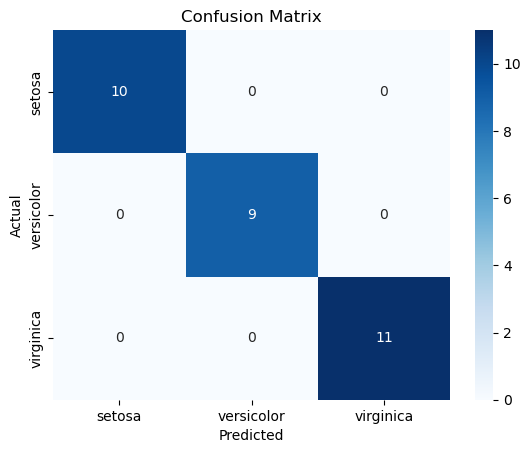

In [88]:
# Train the model with K=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [62]:
# Predict a new sample (scaled input)
sample = [[5.1, 3.5, 1.4, 0.2]]  # Example from dataset
sample_scaled = scaler.transform(sample)  # Scale input

prediction = knn.predict(sample_scaled)
print(f"Predicted class: {prediction[0]}")


Predicted class: setosa


c:\Users\franc\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


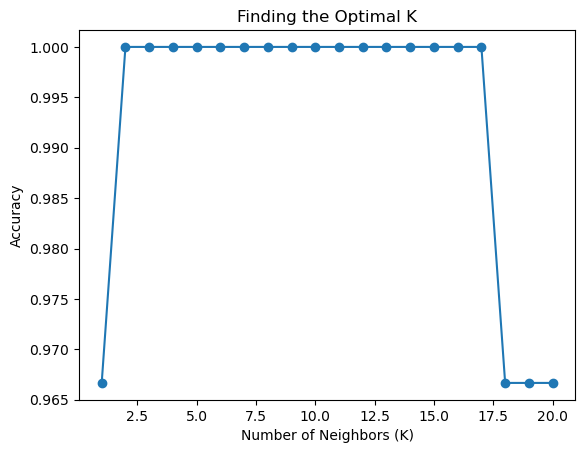

In [63]:
# Test different K values
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot accuracy vs K value
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Finding the Optimal K")
plt.show()


In [64]:
import joblib

# Save the model
joblib.dump(knn, "knn_model.pkl")

['knn_model.pkl']

In [65]:
# Load the model
loaded_knn = joblib.load("knn_model.pkl")

# Make a prediction using the loaded model
prediction = loaded_knn.predict(sample_scaled)
print(f"Predicted class (loaded model): {prediction[0]}")

Predicted class (loaded model): setosa


implemented KNN for flower classification using the Iris dataset.

preprocessed the data, trained the model, evaluated performance, and optimized KNN.

saved and loaded the model for future use.

# example 3

In [76]:
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\prostate.csv")
df.head()

,lcavol,lweight,age,lbph,lcp,gleason,pgg45,lpsa,Target
0,-0.579818,2.769459,50,-1.386294,-1.386294,6,0,-0.430783,0
1,-0.994252,3.319626,58,-1.386294,-1.386294,6,0,-0.162519,0
2,-0.510826,2.691243,74,-1.386294,-1.386294,7,20,-0.162519,0
3,-1.203973,3.282789,58,-1.386294,-1.386294,6,0,-0.162519,0
4,0.751416,3.432373,62,-1.386294,-1.386294,6,0,0.371564,0


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df.drop('Target', axis=1))
scaled_features = scaler.transform(df.drop('Target',
                                           axis=1))
 
df_feat = pd.DataFrame(scaled_features,
                       columns=df.columns[:-1])
df_feat.head()

,lcavol,lweight,age,lbph,lcp,gleason,pgg45,lpsa
0,-1.645861,-2.016634,-1.872101,-1.030029,-0.867655,-1.047571,-0.868957,-2.533318
1,-1.999313,-0.725759,-0.791989,-1.030029,-0.867655,-1.047571,-0.868957,-2.299712
2,-1.587021,-2.200154,1.368234,-1.030029,-0.867655,0.344407,-0.156155,-2.299712
3,-2.178174,-0.812191,-0.791989,-1.030029,-0.867655,-1.047571,-0.868957,-2.299712
4,-0.510513,-0.461218,-0.251933,-1.030029,-0.867655,-1.047571,-0.868957,-1.834631


In [78]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(scaled_features,
                                       df['Target'],
                                       test_size=0.30,random_state=42)


# we are trying to come up
# with a model to predict whether
# someone is Target or not.
# We'll start with k = 1.

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
 
# Predictions and Evaluations
# Let's evaluate our KNN model !
print('WITH K = 1')
print('Confusion Matrix')
print(confusion_matrix(y_test, pred))
print('Classification Report')
print(classification_report(y_test, pred))

WITH K = 1
Confusion Matrix
[[21  4]
 [ 3  2]]
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77        30
   macro avg       0.60      0.62      0.61        30
weighted avg       0.78      0.77      0.77        30



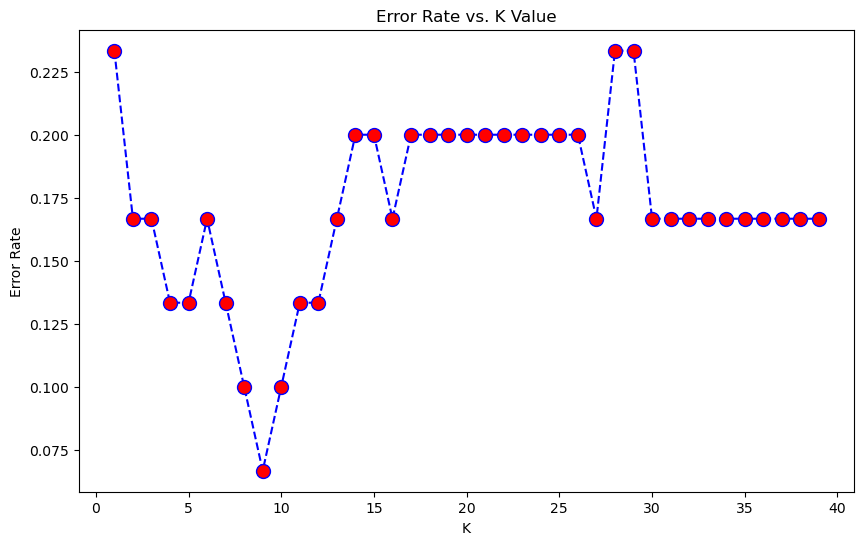

In [79]:
# Elbow Method, use the elbow method to pick a good K Value.
error_rate = []

# Will take some time
for i in range(1, 40):
 
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
 
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue',
         linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
 
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()



we can observe that the error value is oscillating and then it increases to become saturated approximately. So, let’s take the value of K equal to 10 as that value of error is quite redundant.

In [80]:
# NOW WITH K = 10
knn = KNeighborsClassifier(n_neighbors = 10)
 
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
 
print('WITH K = 10')
print('Confusion Matrix')
print(confusion_matrix(y_test, pred))
print('Classification Report')
print(classification_report(y_test, pred))

WITH K = 10
Confusion Matrix
[[23  2]
 [ 1  4]]
Classification Report
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        25
           1       0.67      0.80      0.73         5

    accuracy                           0.90        30
   macro avg       0.81      0.86      0.83        30
weighted avg       0.91      0.90      0.90        30



# Advantages of KNN:
It is easy to understand and implement.

It can also handle multiclass classification problems.

Useful when data does not have a clear distribution.

It works on a non-parametric approach.
# Disadvantages of KNN:
Sensitive to the noisy features in the dataset.

Computationally expansive for the large dataset.

It can be biased in the imbalanced dataset.

Requires the choice of the appropriate value of K.

Sometimes normalization may be required.
